- Добавить другие признаки помимо лагов 
- Добавить валидацию не холдаут, а роллинг (или бэктестинг)
- Разные способы ансамблирования
- Разные датасеты под разные задачи

# Домашнее задание №2

### ИИ 2025-2026. Анализ временных рядов

**Выдано:** 28.01.2026

- **Мягкий дедлайн:** 11.02.2026 23:59
- **Жесткий дедлайн:** 18.02.2026 23:59

За каждый день просрочки после мягкого дедлайна снимается 1 балл.

```
Обратите внимание, что если у ассистента возникают подозрения по честному выполнению заданий (плагиат, чрезмерное использование LLM и/или использование LLM без указания промпта), то он может поставить вам устное собеседование по проделанной работе, по итогам которого он вправе обнулить вам работу.
```

Во второй домашней работе будем работать с ML моделями для прогнозирования временных рядов и рассмотрим несколько дополнительных сюжетов, которые не были затронуты на занятиях, но которые тесно с ними связаны.

В этот раз будем работать не в рамках одного ноутбука, а с использованием нескольких скриптов, которые находятся в папке `modules`. Это сделано для того, чтобы приблизить выполнение домашнего задания к реальным условиям работы с ML проектами.

В начале вас может напугать то, что теперь нужно работать с несколькими файлами, в которых еще и много кода но на самом деле большую часть кода мы уже разобрали на занятиях, и вам останется только реализовать несколько небольших функций и классов. Зато это позволит вам научиться работать с проектами, которые состоят из нескольких файлов, а также читать и понимать чужой код.

In [1]:
import random
from typing import Sequence, Tuple, Union

# Будем использовать CatBoost в качестве базовой модели
import catboost as cb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Рисование графиков
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler

# Быстрый прогон бейзлайн моделей
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, AutoTheta, Naive, SeasonalNaive

In [2]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)


seed_everything()

На седьмом занятии мы рассмотрели с вами такую тему как стратегии прогнозирования на несколько шагов вперед. Мы рассмотрели несколько стратегий, но реализовали только Recursive, из которой вытекает Recursive-MIMO и MIMO. 

Давайте теперь реализуем еще одну стратегию — Direct (а заодно сразу получим и Direct-MIMO).  

### Задание 1: Загрузка данных и определение условий задачи прогнозирования (1 балл)

В этом задании возьмем датасет [METR-LA](https://drive.google.com/drive/folders/10FOTa6HXPqX8Pf5WRoRwcFnW9BrNZEIX), который содержит временные ряды скорости движения с 207 дорожных сенсоров, расположенных на автомагистралях округа Лос-Анджелес. Измерения агрегированы с шагом 5 минут и покрывают наблюдения с 2012-03-01 по 2012-06-28. 

Мы заранее сделали ресемплирование до 60 минут, а так же оставили только последние 10 недель данных (чтобы обучение не занимало слишком много времени) и 10 случайных рядов. Более того, мы привели данные к более удобному виду, где датафрейм представлен в виде трех столбцов: `timestamp`, `sensor_id`, `value`.

__Подгрузите данные из файла `metr-la_preprocessed.csv` (0 баллов).__

In [3]:
# --- Your code here ---

df = pd.read_csv("metr-la_preprocessed.csv")

# Возьмем небольшой сэмпл для ускорения вычислений
random_ids = random.sample(df["sensor_id"].unique().tolist(), 10)
df = df[df["sensor_id"].isin(random_ids)].reset_index(drop=True)

print(df.head(5))

             timestamp  sensor_id      value
0  2012-04-18 23:00:00     773062  64.997685
1  2012-04-19 00:00:00     773062  65.455357
2  2012-04-19 01:00:00     773062  65.741898
3  2012-04-19 02:00:00     773062  64.711806
4  2012-04-19 03:00:00     773062  64.439153


__Выведите типы данных в датасете. Проверьте, что они корректные: даты должны быть в формате datetime, а значения — в float. id оставьте в int. Если это не так, то исправьте их (0.1 балла).__

In [4]:
# --- Your code here ---
print(df.dtypes)
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(df.dtypes)

timestamp     object
sensor_id      int64
value        float64
dtype: object
timestamp    datetime64[ns]
sensor_id             int64
value               float64
dtype: object


__Проверьте, есть ли в данных пропуски. Если они есть, то заполните их предыдущими значениями. Если пропусков нет, то просто выведите сообщение об этом (0.1 балла).__

In [5]:
if df.isnull().any().any():
    df.ffill(inplace=True)
else:
    print("Нет пропусков")

Нет пропусков


__Постройте линейные графики десяти случайных рядов из датасета. По оси X отложите время, по оси Y — значения временного ряда. Ответьте на вопросы ниже. (0.5 баллов)__

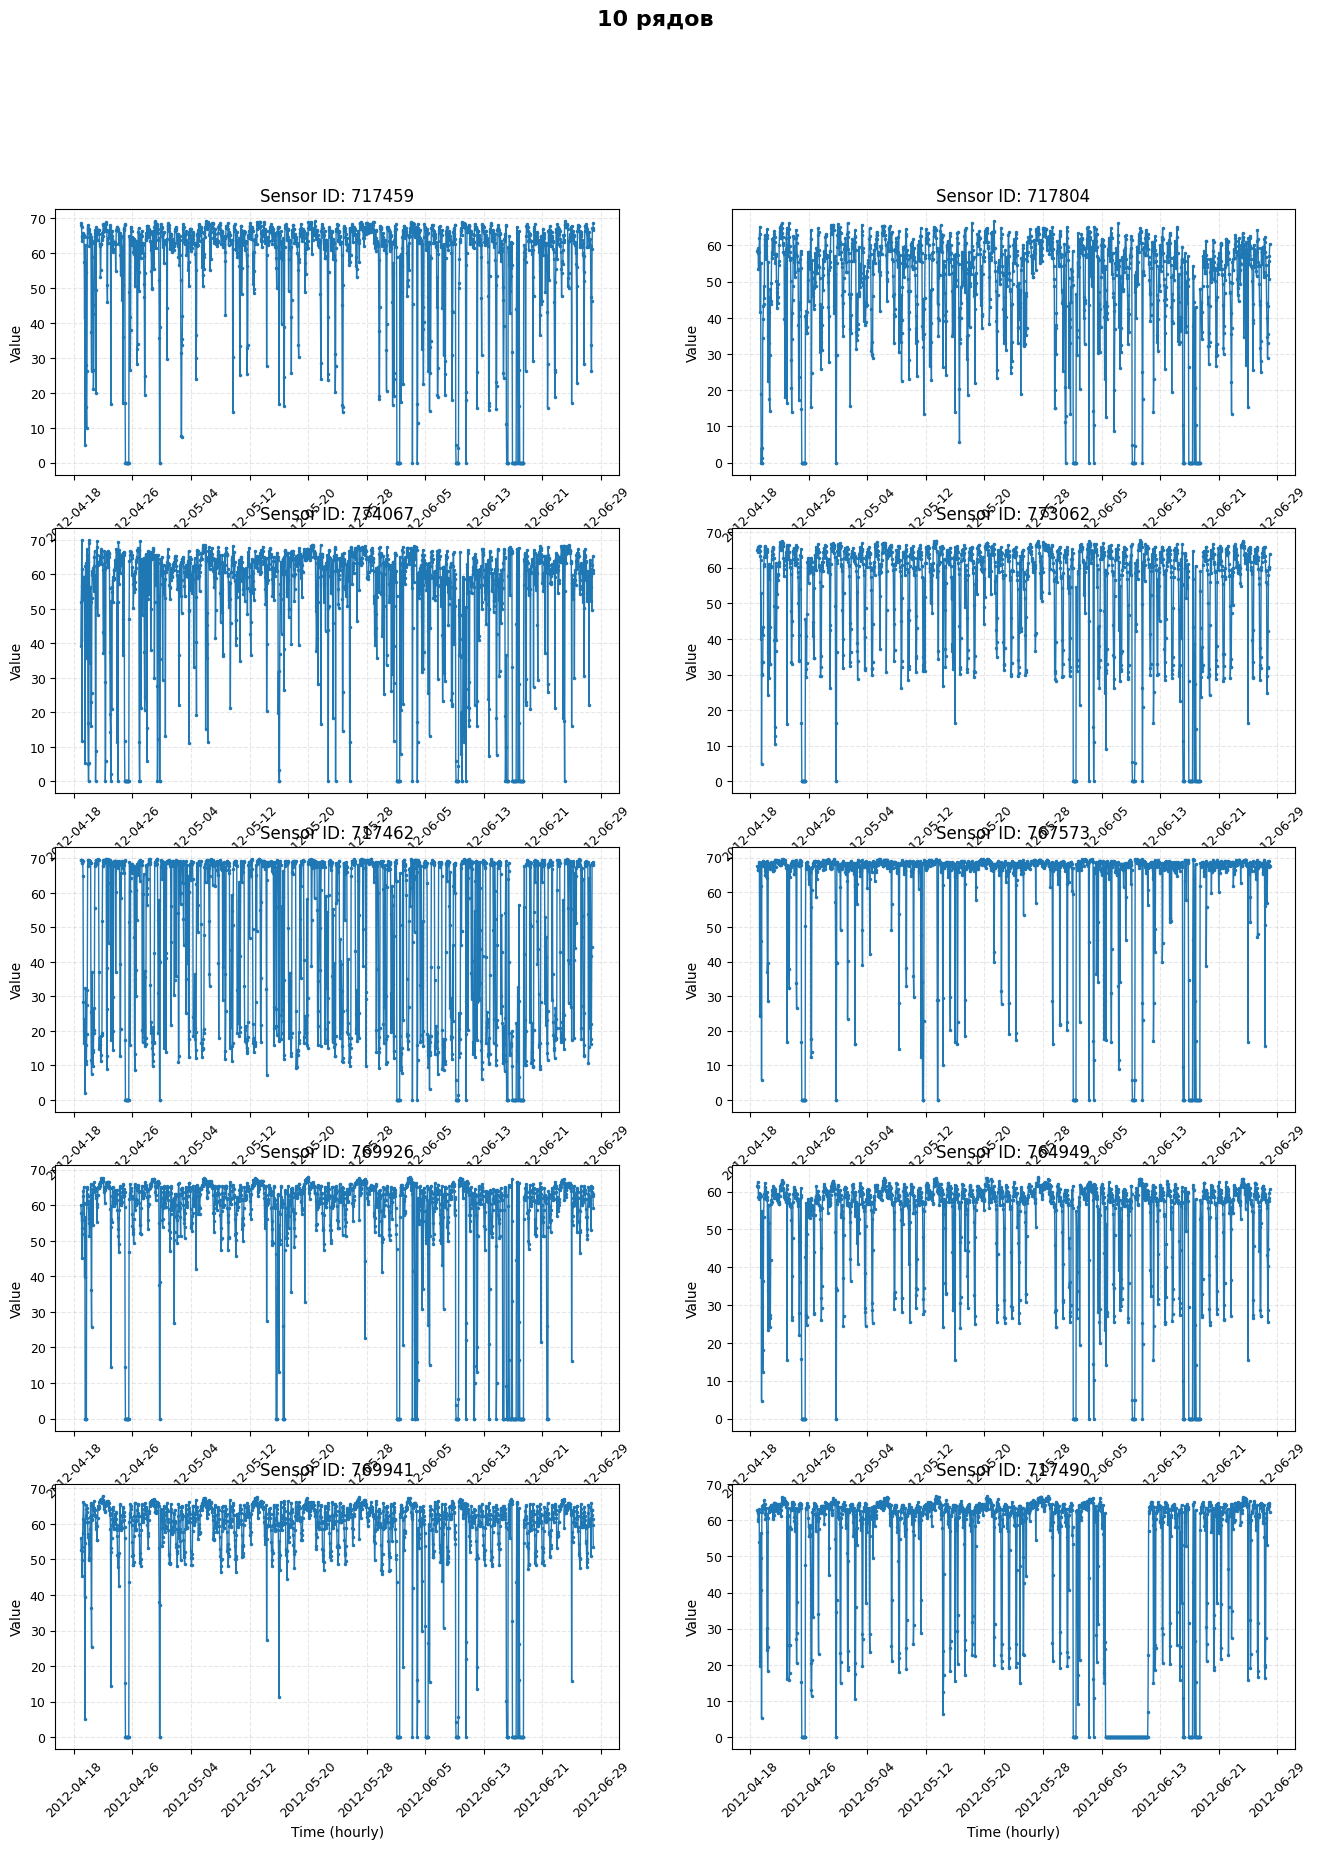

In [6]:
random_sensor_ids = np.random.choice(df['sensor_id'].unique(), size=10, replace=False)
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for i, sensor_id in enumerate(random_sensor_ids):
    sensor_data = df[df['sensor_id'] == sensor_id].sort_values('timestamp')

    axes[i].plot(
        sensor_data['timestamp'],
        sensor_data['value'],
        marker='.',        
        linestyle='-',
        linewidth=1,      
        markersize=3
    )

    axes[i].set_title(f'Sensor ID: {sensor_id}', fontsize=12)
    axes[i].set_xlabel('Time (hourly)', fontsize=10)
    axes[i].set_ylabel('Value', fontsize=10)
    axes[i].grid(True, alpha=0.3, linestyle='--')

    axes[i].xaxis.set_major_locator(plt.MaxNLocator(10))
    axes[i].tick_params(axis='x', rotation=45, labelsize=9)
    axes[i].tick_params(axis='y', labelsize=9)

plt.suptitle(
    '10 рядов',
    fontsize=16,
    fontweight='bold',
    y=0.98
)
plt.show()


__Ответьте на следующие вопросы:__
- Какова частотность (frequency) данных?
- Являются ли временные ряды выровненными (начинаются и заканчиваются в одно и то же время)?
- Стационарны ли временной ряд? Если нет, то какие признаки нестационарности вы можете выделить? Если в данных есть сезонность, по каков ее период?
- Похожи ли между собой разные временные ряды? Какие закономерности вы можете выделить?

1 - Частотность данных - часовая,

2 - Да, временные ряды выровненные - начинается и заканчиваются в одно и тоже время

3 - Ряды нестационарны: тренда нет, дисперсия разная, сезонность - скорость снижена во многих точках

4 - Да, ряда похожи. Схожая сезонность - то сть в определенное время поддерживается одна и та же скорость, есть колебания - в сторону маленьких скоростей - может аварии или пробки

__Для подтверждения периода сезонности постройте графики автокорреляционной функции (ACF) для трех рядов из нарисованных выше.__

__Замените нули временного ряда на локальное среднее в окне 5, чтобы избежать ложных пиков (0.3 балла).__ `Но не оставляйте их для следующих заданий (верните эти значения на 0).`

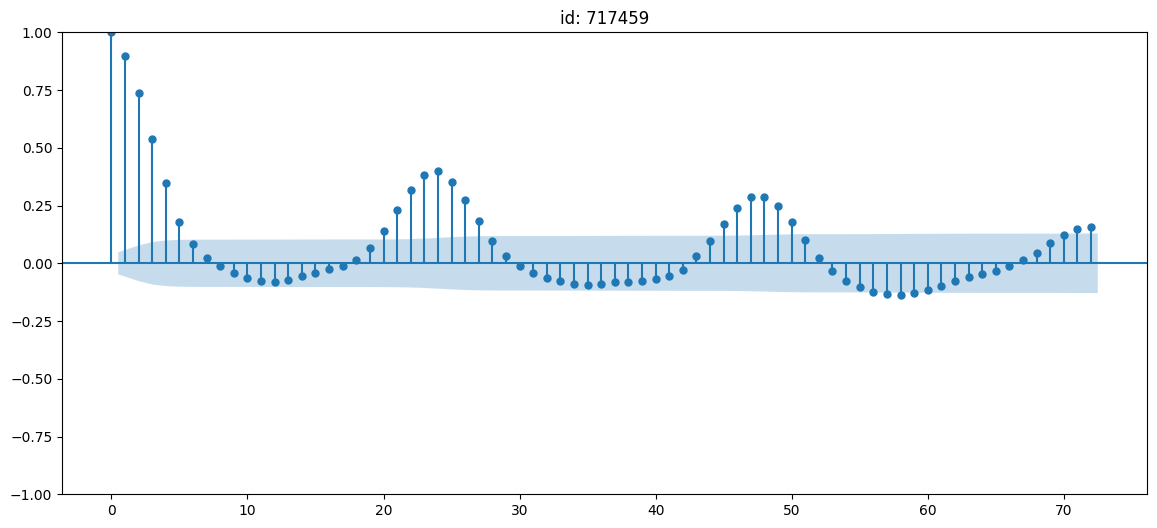

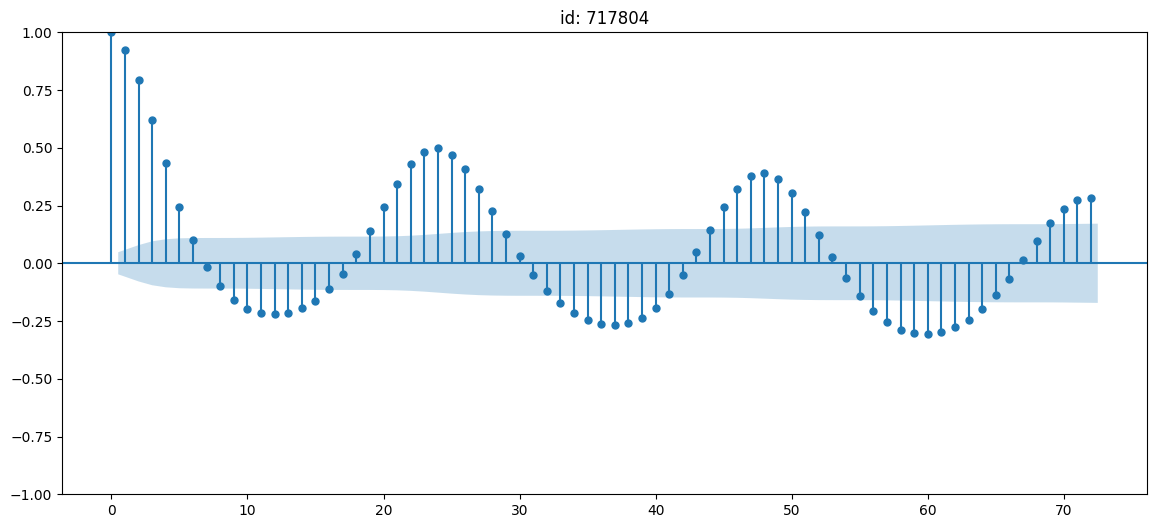

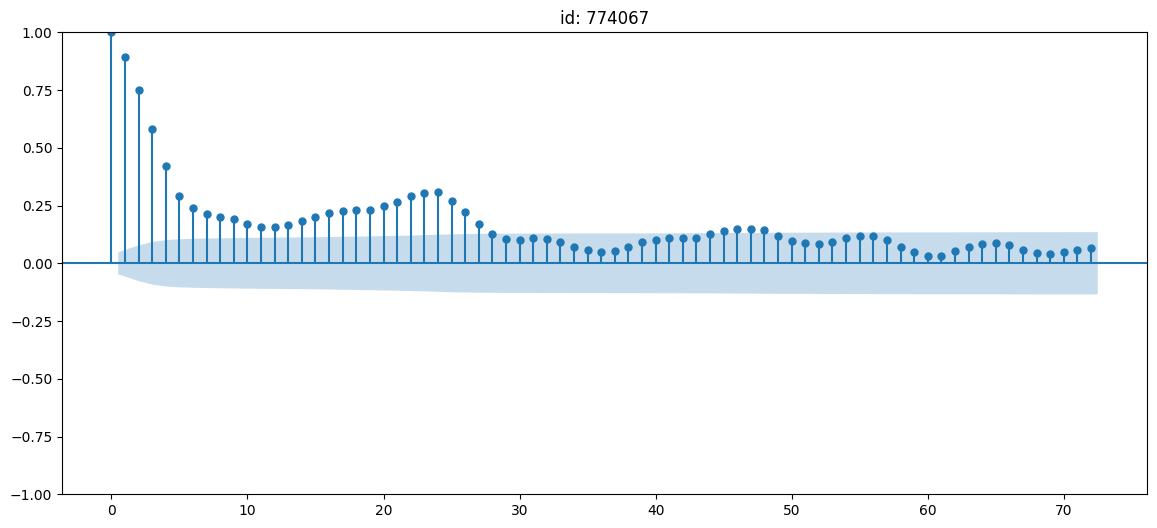

In [22]:
from statsmodels.graphics.tsaplots import plot_acf

# --- Your code here ---
ryads_3 = pd.Series(df['sensor_id'].unique()).sample(3, random_state=42).tolist()
id1, id2, id3 = ryads_3[0], ryads_3[1], ryads_3[2]

ts1 = df[df['sensor_id'] == id1].copy()
ts2 = df[df['sensor_id'] == id2].copy()
ts3 = df[df['sensor_id'] == id3].copy()

tses = [ts1, ts2, ts3]
for i in range(len(tses)):
    tses[i]['value'] = (
        tses[i]['value']
        .replace(0, np.nan)
        .rolling(window=5, center=True, min_periods=1)
        .mean()
        .bfill()
        .ffill()
    )
    
for i in range(len(tses)):
    fig, ax = plt.subplots(figsize=(14, 6))
    plot_acf(tses[i]['value'], lags=72, ax=ax)
    plt.title(f'id: {ryads_3[i]}')
    plt.show()

В основном видим ярко выраженную сезонность: пики на 24, 48, 72 (только третий ряд чуть выбивается в этом плане) + она зачастую выходит за доверительный интервал.



Зафиксируем следующие параметры задачи прогнозирования:
- История (длина входного окна): 24 часа (24 точки при частоте 1 час)
- Горизонт прогнозирования (длина выходного окна): 12 часов (12 точек при частоте 1 час)
- Валидация: expanding (с расширяющимся окном обучения), шаг 1 неделя, начиная с 6 недель обучения. На валидационный набор отводится так же 1 неделя. Здесь валидационный набор — это те данные, которые используются для подбора гиперпараметров модели (в нашем случае early stopping).

In [6]:
HISTORY = 24
HORIZON = 12
START_TRAIN_SIZE = 6 * 7 * 24  # 6 недель
STEP_SIZE = 7 * 24  # 1 неделя

SEASON_LENGTH = 24  # Суточная сезонность
FREQ = "h"  # Частота временного ряда, нужна для StatsForecast

### Задание 2: Реализация валидации с расширяющимся окном обучения и построение бейзлайнов при помощи statsforecast (1 балл)

__Дополните функцию валидации с расширяющимся окном обучения, которая находится в `modules/validation.py`.__

Обратите внимание, что валидационный датасет должен включать в себя `history` точек из конца трейна, помимо собственных 12 точек валидации. Аналогично, тестовый датасет должен включать в себя `history` точек из конца трейна + валидации, помимо собственных 12 точек теста.

Класс StatsforecastModel в `modules/models.py` написан за вас.

Давайте проверим, что всё сделано верно.

In [7]:
import os
import sys

project_root = r"D:\PyCharm Projects\TIME_SERIES_2"
sys.path.insert(0, project_root)

import modules

from modules.validation import expanding_window_validation
from modules.models import StatsforecastModel
from statsforecast.models import AutoETS, AutoTheta, Naive, SeasonalNaive


In [10]:
all_results = {}

for model, model_name in [
    (StatsforecastModel(Naive(), FREQ, HORIZON), "Naive"),
    (StatsforecastModel(SeasonalNaive(season_length=SEASON_LENGTH), FREQ, HORIZON), "SeasonalNaive"),
    (StatsforecastModel(AutoETS(season_length=SEASON_LENGTH), FREQ, HORIZON), "AutoETS"),
    (StatsforecastModel(AutoTheta(season_length=SEASON_LENGTH), FREQ, HORIZON), "AutoTheta"),
]:
    print(f"Evaluating model: {model_name}")
    results_df = expanding_window_validation(
        data=df,
        model=model,
        horizon=HORIZON,
        history=HISTORY,
        start_train_size=START_TRAIN_SIZE,
        step_size=STEP_SIZE,
        id_col="sensor_id",
        timestamp_col="timestamp",
        value_col="value",
    )

    all_results[model_name] = results_df

Evaluating model: Naive
Evaluating model: SeasonalNaive
Evaluating model: AutoETS
Evaluating model: AutoTheta


Для того, чтобы проверить корректность реализации, проверьте получившиеся у вас графики с авторскими. Функцию для отрисовки графиков мы берем на себя :)

In [11]:
all_results_df = (
    pd.concat(all_results.values(), keys=all_results.keys(), names=["model", "row_id"])
    .reset_index()
    .drop(columns=["row_id"])
)
all_results_df

,model,sensor_id,fold,timestamp,true_value,predicted_value
0,Naive,773062,0,2012-05-31 11:00:00,57.728009,62.630787
1,Naive,773062,0,2012-05-31 12:00:00,52.985053,62.630787
2,Naive,773062,0,2012-05-31 13:00:00,57.393519,62.630787
3,Naive,773062,0,2012-05-31 14:00:00,34.306713,62.630787
4,Naive,773062,0,2012-05-31 15:00:00,29.534722,62.630787
...,...,...,...,...,...,...
1915,AutoTheta,769926,3,2012-06-21 18:00:00,0.000000,57.563088
1916,AutoTheta,769926,3,2012-06-21 19:00:00,53.943618,68.005625
1917,AutoTheta,769926,3,2012-06-21 20:00:00,64.030093,71.690293
1918,AutoTheta,769926,3,2012-06-21 21:00:00,63.245370,69.276292


In [15]:
def plot_results_expanding_cv(
    df: pd.DataFrame,
    forecast_df: pd.DataFrame,
    id_column: str = "sensor_id",
    time_column: str = "timestamp",
    forecast_column: str = "predicted_value",
    target_column_df: str = "value",
    target_column_forecast_df: str = "true_value",
    fold_column_forecast_df: str = "fold",
    model_column_forecast_df: str = "model",
    num_samples_to_plot: int = 3,
    seed: int = 42,
):
    """Визуализирует expanding window CV.
    Args:
        df: Датафрейм с реальными значениями.
        forecast_df: Датафрейм с прогнозами и информацией о фолдах.
        id_column: Название колонки с идентификатором временного ряда.
        time_column: Название колонки с временной меткой.
        forecast_column: Название колонки с прогнозами.
        target_column_df: Название колонки с реальными значениями в df.
        target_column_forecast_df: Название колонки с реальными значениями в forecast_df.
        fold_column_forecast_df: Название колонки с фолдами в forecast_df.
        model_column_forecast_df: Название колонки с именами моделей в forecast_df.
        num_samples_to_plot: Количество случайных рядов для визуализации.
        seed: random seed для воспроизводимости.

    """
    colors = {
        "history_true": "grey",
        "forecast_true": "blue",
        "forecast_models": px.colors.qualitative.Plotly
    }
    
    random.seed(seed)
    sampled_ids = random.sample(
        forecast_df[id_column].dropna().unique().tolist(), num_samples_to_plot
    )

    num_folds = forecast_df[fold_column_forecast_df].nunique()
    for series_id in sampled_ids:
        current_df = df[df[id_column] == series_id]
        current_forecast_df = forecast_df[forecast_df[id_column] == series_id]

        fig = make_subplots(
            rows=num_folds,
            cols=1,
            shared_xaxes=True,
            vertical_spacing=0.12,
            subplot_titles=[f"fold={f}" for f in range(num_folds)],
        )

        for fold_idx in range(num_folds):
            current_fold_forecast_df = current_forecast_df[
                current_forecast_df[fold_column_forecast_df] == fold_idx
            ]
            test_start_timestamp = current_fold_forecast_df[time_column].min()

            history = current_df[current_df[time_column] < test_start_timestamp]

            fig.add_trace(
                go.Scatter(
                    x=history[time_column],
                    y=history[target_column_df],
                    mode="lines",
                    name="History (train+val)",
                    legendgroup="history",
                    line=dict(color=colors["history_true"]),
                    showlegend=(fold_idx == 0),
                ),
                row=fold_idx + 1,
                col=1,
            )
            for i, model_name in enumerate(sorted(
                current_fold_forecast_df[model_column_forecast_df].dropna().unique().tolist()
            )):                
                mdf = current_fold_forecast_df[
                    current_fold_forecast_df[model_column_forecast_df] == model_name
                ]
                if i == 0:
                    fig.add_trace(
                        go.Scatter(
                            x=mdf[time_column],
                            y=mdf[target_column_forecast_df],
                            mode="lines",
                            name="True (test)",
                            legendgroup="true_test",
                            line=dict(color=colors["forecast_true"]),
                            showlegend=(fold_idx == 0),
                        ),
                        row=fold_idx + 1,
                        col=1,
                    )
                fig.add_trace(
                    go.Scatter(
                        x=mdf[time_column],
                        y=mdf[forecast_column],
                        mode="lines",
                        line=dict(dash="dash", color=colors["forecast_models"][i % len(colors["forecast_models"])]),
                        name=str(model_name),
                        legendgroup=str(model_name),
                        showlegend=(fold_idx == 0),
                    ),
                    row=fold_idx + 1,
                    col=1,
                )
        fig.update_layout(
            title=f"Expanding CV: sensor_id={series_id}",
        )
        fig.show()

In [13]:
plot_results_expanding_cv(df, all_results_df, num_samples_to_plot=1)

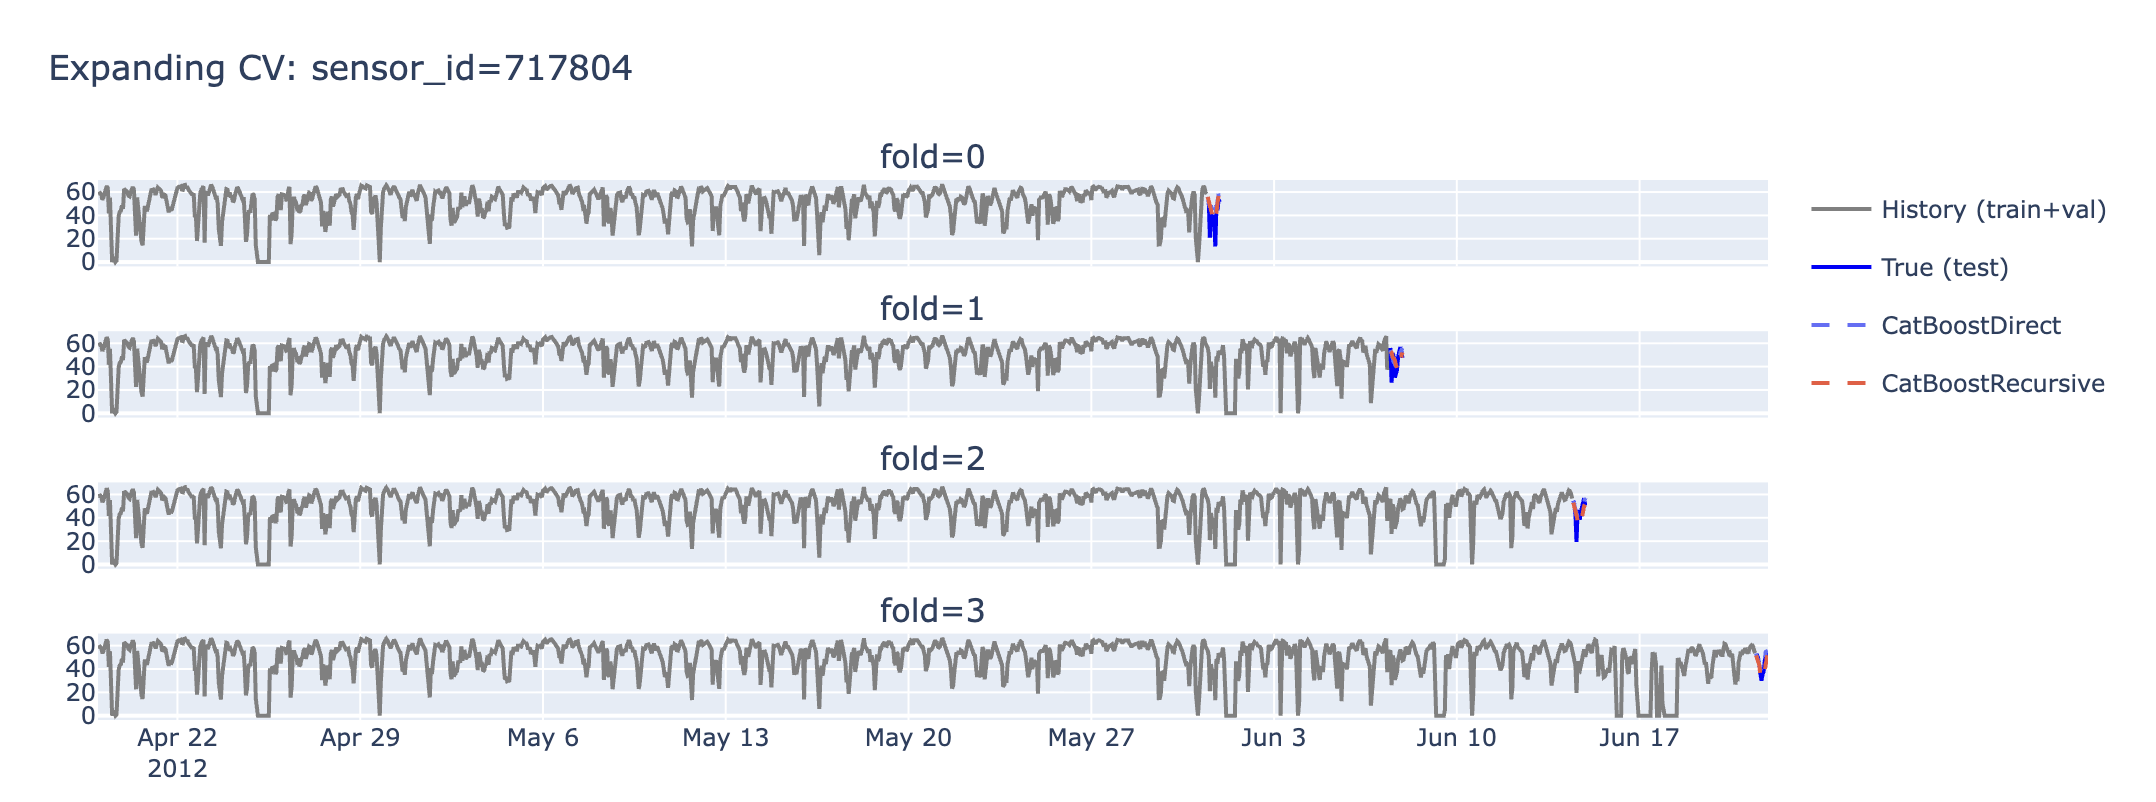

### Задание 3: Реализация метрик (0.5 балла)

Давайте будем использовать в качестве метрик ту, которую мы еще не брали ранее и которая была рекомендована в курсе [Christoph Bergmeir](https://www.youtube.com/watch?v=hrfEGmZjips) как еще одна замена классической метрики MAPE.

WAPE (Weighted Absolute Percentage Error) рассчитывается по формуле:

$$WAPE = \frac{\sum_{t=T+1}^{T+H} |y_t - \hat{y}_t|}{\sum_{t=T+1}^{T+H} |y_t|}$$

где:
- $H$ — горизонт прогнозирования
- $T$ — длина исторических данных
- $y_t$ — истинные значения временного ряда на горизонте прогнозирования
- $\hat{y}_t$ — предсказанные значения временного ряда на горизонте прогнозирования

От MAPE отличается тем, что суммы берутся вне дроби, что позволяет избежать деления на ноль и на малые значения. Можно сказать, что мы взвешиваем общую абсолютную ошибку по абсолютным значениям временного ряда (сколько процентов от общего объема мы ошиблись). 

__Реализуйте расчет этих метрик в функции `calculate_metrics`.__

In [18]:
def calculate_wape(
    group: pd.DataFrame, pred_column: str = "predicted_value", true_column: str = "true_value"
) -> pd.Series:
    """Вычисляет метрику WAPE.

    Args:
        group: Датафрейм с прогнозами и реальными значениями.
        pred_column: Название колонки с прогнозами.
        true_column: Название колонки с реальными значениями.

    Returns:
        pd.Series с рассчитанной метрикой WAPE.

    """
    # --- Your code here ---
    error = (group[pred_column] - group[true_column]).abs()
    tru_sum = group[true_column].sum()
    wape = error.sum() / tru_sum

    print(wape)

    return pd.Series({"WAPE": wape})

Если всё сделано правильно, то следующая ячейка запуститься без ошибок.

In [15]:
metrics_df = (
    all_results_df
    .groupby(["model", "fold"], as_index=False)
    .apply(calculate_wape, include_groups=False)
    .reset_index(drop=True)
)

print("WAPE по моделям и фолдам:")
display(metrics_df)

print("Среднее и стандартное отклонение WAPE по моделям:")
display(metrics_df.groupby("model").agg({"WAPE": ["mean", "std"]}))

0.2503589752527414
0.5672902500517332
0.23431287730571196
0.2322827280071348
0.2248827959611558
0.5341536552736639
0.21729538775387125
0.22220307565392833
0.23665158663082758
0.5445343419977391
0.23494897419258473
0.23524951868610142
0.21338424316897442
0.5489406023221605
0.2606210540226725
0.2623974381670717
WAPE по моделям и фолдам:


,model,fold,WAPE
0,AutoETS,0,0.250359
1,AutoETS,1,0.567290
2,AutoETS,2,0.234313
3,AutoETS,3,0.232283
4,AutoTheta,0,0.224883
5,AutoTheta,1,0.534154
6,AutoTheta,2,0.217295
7,AutoTheta,3,0.222203
8,Naive,0,0.236652
9,Naive,1,0.544534


Среднее и стандартное отклонение WAPE по моделям:


WAPE          
                   mean       std
model                            
AutoETS        0.321061  0.164352
AutoTheta      0.299634  0.156378
Naive          0.312846  0.154461
SeasonalNaive  0.321336  0.153425

### Задание 4: Реализация Direct и Direct-MIMO (4.5 балла)

__Реализуйте модель CatBoostDirect в файле `modules/models.py`__ аналогично тому, как мы реализовали стратегию Recursive на семинаре. Для примера CatBoostRecursive модель уже приведена в формате класса.

Обратите внимание, что все нужные функции для работы с индексами находятся в файле `modules/index_slicing.py`.

Если в случае с рекурсивной стратегией в случае `model_horizon=1` мы обучали одну модель на один шаг вперед, то в случае с Direct стратегией нам нужно обучать по одной модели на каждый шаг из горизонта прогнозирования. То есть в аттрибутах класса CatBoostDirect self.models должно быть $H$ моделей CatBoost, где $H$ — горизонт прогнозирования.

__Вам необходимо понять, как изменить код рекурсивной стратегии так, чтобы реализовать Direct стратегию.__

Если все сделано правильно, то следующие ячейки должны запуститься без ошибок.

In [9]:
from modules.models import CatBoostRecursive, CatBoostDirect

In [17]:
recursive_results = expanding_window_validation(
    data=df,
    model=CatBoostRecursive(
        model_horizon=1,
        history=HISTORY,
        horizon=HORIZON,
        freq=FREQ,
    ),
    horizon=HORIZON,
    history=HISTORY,
    start_train_size=START_TRAIN_SIZE,
    step_size=STEP_SIZE,
    id_col="sensor_id",
    timestamp_col="timestamp",
    value_col="value",
)

0:	learn: 14.2043938	test: 13.6638304	best: 13.6638304 (0)	total: 183ms	remaining: 4m 34s
100:	learn: 7.8157675	test: 9.2898174	best: 9.2898174 (100)	total: 5.47s	remaining: 1m 15s
200:	learn: 7.1728487	test: 8.8553778	best: 8.8522558 (198)	total: 9.3s	remaining: 1m
300:	learn: 6.7899963	test: 8.6400919	best: 8.6400919 (300)	total: 13s	remaining: 51.9s
400:	learn: 6.5010819	test: 8.5189263	best: 8.5189263 (400)	total: 16.7s	remaining: 45.9s
500:	learn: 6.2059135	test: 8.3664737	best: 8.3651725 (499)	total: 20.5s	remaining: 40.9s
600:	learn: 5.9830990	test: 8.2822996	best: 8.2733286 (591)	total: 24.2s	remaining: 36.3s
700:	learn: 5.7589105	test: 8.1607811	best: 8.1607811 (700)	total: 28s	remaining: 31.9s
800:	learn: 5.5807579	test: 8.0828063	best: 8.0828063 (800)	total: 31.8s	remaining: 27.7s
900:	learn: 5.4125978	test: 8.0461852	best: 8.0375941 (888)	total: 35.5s	remaining: 23.6s
1000:	learn: 5.2656976	test: 8.0181393	best: 8.0123424 (982)	total: 39.2s	remaining: 19.5s
1100:	learn: 5.1

In [19]:
direct_results = expanding_window_validation(
    data=df,
    model=CatBoostDirect(
        model_horizon=1,
        history=HISTORY,
        horizon=HORIZON,
        freq=FREQ,
    ),
    horizon=HORIZON,
    history=HISTORY,
    start_train_size=START_TRAIN_SIZE,
    step_size=STEP_SIZE,
    id_col="sensor_id",
    timestamp_col="timestamp",
    value_col="value",
)

Проверка для себя - очистил
train_targets.shape = (20020, 12)
val_targets.shape = (580, 12)
Learning rate set to 0.104584
0:	learn: 13.5667482	test: 13.6808178	best: 13.6808178 (0)	total: 89.4ms	remaining: 44.6s
100:	learn: 6.5494888	test: 8.9042266	best: 8.9029690 (97)	total: 8.74s	remaining: 34.5s
200:	learn: 5.7840884	test: 8.5362414	best: 8.5362414 (200)	total: 16.6s	remaining: 24.7s
300:	learn: 5.2966386	test: 8.4394602	best: 8.4224351 (288)	total: 24.3s	remaining: 16.1s
400:	learn: 5.0200367	test: 8.2955135	best: 8.2898032 (393)	total: 31.7s	remaining: 7.83s
499:	learn: 4.7821589	test: 8.1755898	best: 8.1755898 (499)	total: 39.4s	remaining: 0us
bestTest = 8.175589768
bestIteration = 499
Trained model for horizon 0/12
train_targets.shape = (20020, 12)
val_targets.shape = (580, 12)
Learning rate set to 0.104584
0:	learn: 13.8169806	test: 14.1639511	best: 14.1639511 (0)	total: 83.3ms	remaining: 41.6s
100:	learn: 7.7580949	test: 12.1290841	best: 12.1290841 (100)	total: 8.06s	remainin

In [20]:
ml_results_df = pd.concat(
    [
        recursive_results.assign(model="CatBoostRecursive"),
        direct_results.assign(model="CatBoostDirect"),
    ],
    ignore_index=True,
)
ml_results_df

,sensor_id,fold,timestamp,true_value,predicted_value,model
0,773062,0,2012-05-31 11:00:00,57.728009,58.144944,CatBoostRecursive
1,773062,0,2012-05-31 12:00:00,52.985053,56.172653,CatBoostRecursive
2,773062,0,2012-05-31 13:00:00,57.393519,51.137863,CatBoostRecursive
3,773062,0,2012-05-31 14:00:00,34.306713,43.183771,CatBoostRecursive
4,773062,0,2012-05-31 15:00:00,29.534722,32.774898,CatBoostRecursive
...,...,...,...,...,...,...
955,769926,3,2012-06-21 18:00:00,0.000000,56.383048,CatBoostDirect
956,769926,3,2012-06-21 19:00:00,53.943618,53.236036,CatBoostDirect
957,769926,3,2012-06-21 20:00:00,64.030093,58.480825,CatBoostDirect
958,769926,3,2012-06-21 21:00:00,63.245370,56.582816,CatBoostDirect


In [21]:
plot_results_expanding_cv(df, ml_results_df, num_samples_to_plot=1)

In [22]:
metrics_df = (
    ml_results_df
    .groupby(["model", "fold"], as_index=False)
    .apply(calculate_wape, include_groups=False)
    .reset_index(drop=True)
)

print("WAPE по моделям и фолдам:")
display(metrics_df)

print("Среднее и стандартное отклонение WAPE по моделям:")
display(metrics_df.groupby("model").agg({"WAPE": ["mean", "std"]}))

0.1308540981751027
0.21304377945132846
0.1719214612403071
0.15817536093475365
0.10942332285655812
0.24887118191758342
0.13554878915246224
0.1384122718966152
WAPE по моделям и фолдам:


,model,fold,WAPE
0,CatBoostDirect,0,0.130854
1,CatBoostDirect,1,0.213044
2,CatBoostDirect,2,0.171921
3,CatBoostDirect,3,0.158175
4,CatBoostRecursive,0,0.109423
5,CatBoostRecursive,1,0.248871
6,CatBoostRecursive,2,0.135549
7,CatBoostRecursive,3,0.138412


Среднее и стандартное отклонение WAPE по моделям:


WAPE          
                       mean       std
model                                
CatBoostDirect     0.168499  0.034252
CatBoostRecursive  0.158064  0.061927

### Задание 5: Сравнение моделей (2 балла)

Возьмите промежуточный вариант стратегий (Direct-MIMO и Recursive-MIMO) с model_horizon = 3. Также возьмите не 10 рядов, а хотя бы 30. Сравните качество получившихся моделей с качеством полных Direct, Recursive и MIMO стратегий (model_horizon = 1). Какой из вариантов показал себя лучше? Почему, на ваш взгляд, так произошло?

In [27]:
# --- Your code here ---

df30 = pd.read_csv("metr-la_preprocessed.csv")
random_ids30 = random.sample(df30["sensor_id"].unique().tolist(), 30)
df30 = df30[df30["sensor_id"].isin(random_ids30)].reset_index(drop=True)

df30.head(20)

,timestamp,sensor_id,value
0,2012-04-18 23:00:00,773062,64.997685
1,2012-04-19 00:00:00,773062,65.455357
2,2012-04-19 01:00:00,773062,65.741898
3,2012-04-19 02:00:00,773062,64.711806
4,2012-04-19 03:00:00,773062,64.439153
5,2012-04-19 04:00:00,773062,64.845040
6,2012-04-19 05:00:00,773062,64.966435
7,2012-04-19 06:00:00,773062,66.111111
8,2012-04-19 07:00:00,773062,66.084821
9,2012-04-19 08:00:00,773062,64.663194


In [29]:
if df30.isnull().any().any():
    df30.ffill(inplace=True)
else:
    print("Нет пропусков")

Нет пропусков


In [31]:
df30['timestamp'] = pd.to_datetime(df30['timestamp'])


In [33]:
direct_results30 = expanding_window_validation(
    data=df30,
    model=CatBoostDirect(
        model_horizon=3,
        history=HISTORY,
        horizon=HORIZON,
        freq=FREQ,
    ),
    horizon=HORIZON,
    history=HISTORY,
    start_train_size=START_TRAIN_SIZE,
    step_size=STEP_SIZE,
    id_col="sensor_id",
    timestamp_col="timestamp",
    value_col="value",
)

Проверка для себя - очистил
train_targets.shape = (198051, 12)
val_targets.shape = (6567, 12)
Learning rate set to 0.133955
0:	learn: 14.1608054	test: 12.9985987	best: 12.9985987 (0)	total: 334ms	remaining: 2m 46s
100:	learn: 5.6715062	test: 7.8730542	best: 7.8730542 (100)	total: 15.2s	remaining: 1m
200:	learn: 4.9168316	test: 7.6480041	best: 7.5781595 (193)	total: 30.2s	remaining: 44.9s
300:	learn: 4.4785423	test: 7.4495106	best: 7.4439351 (286)	total: 45.2s	remaining: 29.9s
400:	learn: 4.1990131	test: 7.3302847	best: 7.3192982 (395)	total: 1m	remaining: 15s
499:	learn: 3.9494760	test: 7.2722498	best: 7.2689900 (475)	total: 1m 15s	remaining: 0us
bestTest = 7.268990005
bestIteration = 475
Shrink model to first 476 iterations.
Trained model for horizon 0/12
train_targets.shape = (198051, 12)
val_targets.shape = (6567, 12)
Learning rate set to 0.133955
0:	learn: 14.5000079	test: 13.4510134	best: 13.4510134 (0)	total: 265ms	remaining: 2m 12s
100:	learn: 6.7127829	test: 10.4328055	best: 10

In [34]:
recursive_results30 = expanding_window_validation(
    data=df30,
    model=CatBoostRecursive(
        model_horizon=3,
        history=HISTORY,
        horizon=HORIZON,
        freq=FREQ,
    ),
    horizon=HORIZON,
    history=HISTORY,
    start_train_size=START_TRAIN_SIZE,
    step_size=STEP_SIZE,
    id_col="sensor_id",
    timestamp_col="timestamp",
    value_col="value",
)

0:	learn: 26.5839347	test: 23.9495586	best: 23.9495586 (0)	total: 664ms	remaining: 16m 35s
100:	learn: 15.3978081	test: 18.5937930	best: 18.5827954 (94)	total: 1m 7s	remaining: 15m 32s
200:	learn: 13.4753399	test: 17.2181199	best: 17.2181199 (200)	total: 2m 16s	remaining: 14m 40s
300:	learn: 12.7270393	test: 16.6190672	best: 16.6186823 (299)	total: 3m 26s	remaining: 13m 42s
400:	learn: 12.1702587	test: 16.1765637	best: 16.1765637 (400)	total: 4m 44s	remaining: 12m 58s
500:	learn: 11.7129103	test: 15.7514883	best: 15.7500884 (499)	total: 5m 57s	remaining: 11m 53s
600:	learn: 11.3803012	test: 15.5954508	best: 15.5954508 (600)	total: 7m 7s	remaining: 10m 40s
700:	learn: 11.0879327	test: 15.4428537	best: 15.4371544 (698)	total: 8m 22s	remaining: 9m 32s
800:	learn: 10.8477411	test: 15.2710700	best: 15.2710700 (800)	total: 9m 41s	remaining: 8m 27s
900:	learn: 10.6460368	test: 15.1501337	best: 15.1488612 (899)	total: 11m	remaining: 7m 19s
1000:	learn: 10.4588460	test: 15.0433064	best: 15.0400

In [35]:
ml_results_df30 = pd.concat(
    [
        recursive_results30.assign(model="CatBoostRecursive"),
        direct_results30.assign(model="CatBoostDirect"),
    ],
    ignore_index=True,
)
ml_results_df30

,sensor_id,fold,timestamp,true_value,predicted_value,model
0,773062,0,2012-05-31 11:00:00,57.728009,55.456470,CatBoostRecursive
1,773062,0,2012-05-31 12:00:00,52.985053,54.796340,CatBoostRecursive
2,773062,0,2012-05-31 13:00:00,57.393519,51.255178,CatBoostRecursive
3,773062,0,2012-05-31 14:00:00,34.306713,51.594206,CatBoostRecursive
4,773062,0,2012-05-31 15:00:00,29.534722,48.725628,CatBoostRecursive
...,...,...,...,...,...,...
2875,769373,3,2012-06-21 18:00:00,49.979167,45.231092,CatBoostDirect
2876,769373,3,2012-06-21 19:00:00,61.766204,55.767058,CatBoostDirect
2877,769373,3,2012-06-21 20:00:00,63.100529,53.668012,CatBoostDirect
2878,769373,3,2012-06-21 21:00:00,62.135417,54.422326,CatBoostDirect


In [36]:
plot_results_expanding_cv(df30, ml_results_df30, num_samples_to_plot=1)

In [37]:
metrics_df30 = (
    ml_results_df30
    .groupby(["model", "fold"], as_index=False)
    .apply(calculate_wape, include_groups=False)
    .reset_index(drop=True)
)

print("WAPE по моделям и фолдам:")
display(metrics_df30)

print("Среднее и стандартное отклонение WAPE по моделям:")
display(metrics_df.groupby("model").agg({"WAPE": ["mean", "std"]}))

0.12042086617994048
0.20235896342485798
0.23115644935009366
0.1496558314726213
0.13533576867465621
0.24793101695946268
0.23187602282959424
0.17447816396208807
WAPE по моделям и фолдам:


,model,fold,WAPE
0,CatBoostDirect,0,0.120421
1,CatBoostDirect,1,0.202359
2,CatBoostDirect,2,0.231156
3,CatBoostDirect,3,0.149656
4,CatBoostRecursive,0,0.135336
5,CatBoostRecursive,1,0.247931
6,CatBoostRecursive,2,0.231876
7,CatBoostRecursive,3,0.174478


Среднее и стандартное отклонение WAPE по моделям:


WAPE          
                       mean       std
model                                
CatBoostDirect     0.168499  0.034252
CatBoostRecursive  0.158064  0.061927

### Задание 6: Добавим больше фичей (1 балл)

Добавьте в функции `get_features_df_and_targets` из файла `modules/feature_generation.py` добавьте несколько оконных признаков (например, скользящие средние или std). Проверьте, улучшилось ли качество лучшей модели при добавлении этих признаков.

In [10]:
# --- Your code here ---

recursive_results_features = expanding_window_validation(
    data=df,
    model=CatBoostRecursive(
        model_horizon=1,
        history=HISTORY,
        horizon=HORIZON,
        freq=FREQ,
    ),
    horizon=HORIZON,
    history=HISTORY,
    start_train_size=START_TRAIN_SIZE,
    step_size=STEP_SIZE,
    id_col="sensor_id",
    timestamp_col="timestamp",
    value_col="value",
)

direct_results_features = expanding_window_validation(
    data=df,
    model=CatBoostDirect(
        model_horizon=1,
        history=HISTORY,
        horizon=HORIZON,
        freq=FREQ,
    ),
    horizon=HORIZON,
    history=HISTORY,
    start_train_size=START_TRAIN_SIZE,
    step_size=STEP_SIZE,
    id_col="sensor_id",
    timestamp_col="timestamp",
    value_col="value",
)

Добавил признаки
Добавил признаки
0:	learn: 14.2043938	test: 13.6638304	best: 13.6638304 (0)	total: 214ms	remaining: 5m 20s
100:	learn: 7.8157675	test: 9.2898174	best: 9.2898174 (100)	total: 9.21s	remaining: 2m 7s
200:	learn: 7.1728487	test: 8.8553778	best: 8.8522558 (198)	total: 17s	remaining: 1m 50s
300:	learn: 6.7899963	test: 8.6400919	best: 8.6400919 (300)	total: 27.2s	remaining: 1m 48s
400:	learn: 6.5010819	test: 8.5189263	best: 8.5189263 (400)	total: 36.2s	remaining: 1m 39s
500:	learn: 6.2059135	test: 8.3664737	best: 8.3651725 (499)	total: 43.5s	remaining: 1m 26s
600:	learn: 5.9830990	test: 8.2822996	best: 8.2733286 (591)	total: 50.7s	remaining: 1m 15s
700:	learn: 5.7589105	test: 8.1607811	best: 8.1607811 (700)	total: 57.9s	remaining: 1m 5s
800:	learn: 5.5807579	test: 8.0828063	best: 8.0828063 (800)	total: 1m 4s	remaining: 56.7s
900:	learn: 5.4125978	test: 8.0461852	best: 8.0375941 (888)	total: 1m 11s	remaining: 47.5s
1000:	learn: 5.2656976	test: 8.0181393	best: 8.0123424 (982)	t

In [13]:
ml_results_df_features = pd.concat(
    [
        recursive_results_features.assign(model="CatBoostRecursive"),
        direct_results_features.assign(model="CatBoostDirect"),
    ],
    ignore_index=True,
)
ml_results_df_features

,sensor_id,fold,timestamp,true_value,predicted_value,model
0,773062,0,2012-05-31 11:00:00,57.728009,58.144944,CatBoostRecursive
1,773062,0,2012-05-31 12:00:00,52.985053,56.172653,CatBoostRecursive
2,773062,0,2012-05-31 13:00:00,57.393519,51.137863,CatBoostRecursive
3,773062,0,2012-05-31 14:00:00,34.306713,43.183771,CatBoostRecursive
4,773062,0,2012-05-31 15:00:00,29.534722,32.774898,CatBoostRecursive
...,...,...,...,...,...,...
955,769926,3,2012-06-21 18:00:00,0.000000,56.383048,CatBoostDirect
956,769926,3,2012-06-21 19:00:00,53.943618,53.236036,CatBoostDirect
957,769926,3,2012-06-21 20:00:00,64.030093,58.480825,CatBoostDirect
958,769926,3,2012-06-21 21:00:00,63.245370,56.582816,CatBoostDirect


In [16]:
plot_results_expanding_cv(df, ml_results_df_features, num_samples_to_plot=1)

In [21]:
metrics_df_features = (
    ml_results_df_features
    .groupby(["model", "fold"], as_index=False)
    .apply(calculate_wape, include_groups=False)
    .reset_index(drop=True)
)

print("WAPE по моделям и фолдам:")
display(metrics_df_features)

print("Среднее и стандартное отклонение WAPE по моделям:")
display(metrics_df_features.groupby("model").agg({"WAPE": ["mean", "std"]}))

0.1308540981751027
0.21304377945132846
0.1719214612403071
0.15817536093475365
0.10942332285655812
0.24887118191758342
0.13554878915246224
0.1384122718966152
WAPE по моделям и фолдам:


,model,fold,WAPE
0,CatBoostDirect,0,0.130854
1,CatBoostDirect,1,0.213044
2,CatBoostDirect,2,0.171921
3,CatBoostDirect,3,0.158175
4,CatBoostRecursive,0,0.109423
5,CatBoostRecursive,1,0.248871
6,CatBoostRecursive,2,0.135549
7,CatBoostRecursive,3,0.138412


Среднее и стандартное отклонение WAPE по моделям:


WAPE          
                       mean       std
model                                
CatBoostDirect     0.168499  0.034252
CatBoostRecursive  0.158064  0.061927

## Бонус (до 3-х баллов):

Попробуйте найти узкие места в коде и оптимизировать его, чтобы обучение и предсказание происходило быстрее. Например, можно попробовать параллелить обучение моделей при помощи многопоточности или многопроцессорности. 

- 3 балла вы получите, если найдете хотя бы 2 способа оптимизации кода и сможете сократить время обучения и Recusive и Direct стратегий до такого значения, чтобы вы смогли получить результаты всех стратегий на всем датасете (207 рядов).
- Меньшее количество баллов будет выставлено в зависимости от того, сколько способов оптимизации вы найдете и насколько сильно сократится время обучения и предсказания.

In [24]:
# --- Your code here ---